# Pond Editor

Defines the pond polygon for Trout Derby, visualizes its shape, and exports `pond_data.json` for Godot.

**Workflow:**
1. Edit the vertex list in the **Configuration** cell — adjust `VERTICES` to taste; add or remove points as needed
2. Run all cells to visualize and analyze the shape
3. Run the **Export** cell to write `project/data/pond_data.json`

All coordinates are in **pixels**, relative to the top-left corner of the 1280×720 canvas.
The pond should be centered near **(640, 360)**. At 15 px/m, the pond is roughly 36 m wide.


In [1]:
import json
import math
import os

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


## Configuration

Edit `VERTICES` to place or adjust pond vertices. Each entry is `[x, y]` in pixels on the 1280×720 canvas.

- Add or remove rows to change the vertex count
- Order matters — vertices are connected in sequence and the last connects back to the first
- The default shape is a placeholder ~550×500 px oval centered at (640, 360); adjust by feel to match your Inkscape mockup


In [2]:
# ── World scale ───────────────────────────────────────────────────────────────
PIXELS_PER_METER = 15       # 15 px = 1 m  (derived from pond width ≈ 550 px / 36 m)
CANVAS_W         = 1280     # pixels
CANVAS_H         = 720      # pixels

# ── Player movement ───────────────────────────────────────────────────────────
PLAYER_SPEED_MPS = 1.1      # m/s  (slightly slower than average walking pace of 1.4 m/s)
PLAYER_SPEED_PPS = round(PLAYER_SPEED_MPS * PIXELS_PER_METER)  # → 17 px/s

# ── Pond vertices ─────────────────────────────────────────────────────────────
# [x, y] in pixels; top-left of canvas is (0, 0)
# Adjust these vertices by feel until the shape hits the right pond feel, then re-run all cells
VERTICES = [
    [565, 150],   # 0 top-leftish
    [750, 180],   # 1 top middle
    [925, 165],   # 2 top right corner
    [910, 275],   # 3 right side upper node
    [925, 380],   # 4 right side middle node
    [880, 500],   # 5 right side lower node
    [800, 600],   # new 6 far bottom right expansion
    [645, 650],   # 6 bottom middle
    [515, 530],   # 7 bottom left corner
    [375, 520],   # 8 left side lower node
    [390, 275],   # 9 left side higher node
]

print(f"Player speed: {PLAYER_SPEED_MPS} m/s  →  {PLAYER_SPEED_PPS} px/s")
print(f"Vertex count: {len(VERTICES)}")


Player speed: 1.1 m/s  →  16 px/s
Vertex count: 11


## Visualize Pond Shape

Plots the pond polygon on the full 1280×720 canvas with:
- Vertex indices and coordinates labeled
- Centroid marked
- Max cast distance circle from the centroid (for sanity-checking pond size)
- 16 px safe-zone margin shown as a dashed border


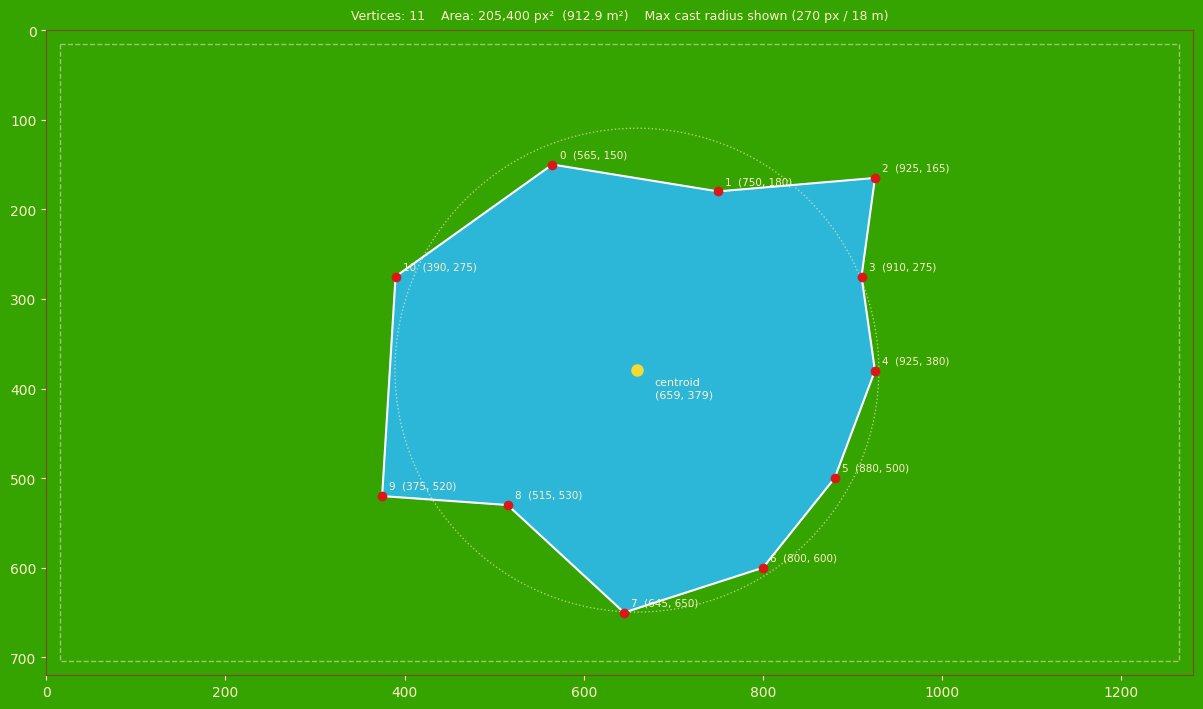

In [3]:
# function to calcualte the centroid of a polygon given its vertices
def compute_centroid(verts):
    """Centroid of a polygon using the weighted shoelace formula."""
    n = len(verts)
    cx = cy = area_signed = 0.0
    for i in range(n):
        x0, y0 = verts[i]
        x1, y1 = verts[(i + 1) % n]
        cross = x0 * y1 - x1 * y0
        area_signed += cross
        cx += (x0 + x1) * cross
        cy += (y0 + y1) * cross
    area_signed *= 0.5
    cx /= 6 * area_signed
    cy /= 6 * area_signed
    return cx, cy, abs(area_signed)


verts = np.array(VERTICES, dtype=float)
cx, cy, area_px2 = compute_centroid(VERTICES)

# Close polygon for plotting
closed = np.vstack([verts, verts[0]])

# Set up the plot
fig, ax = plt.subplots(figsize=(12.8, 7.2), dpi=100)
fig.patch.set_facecolor("#35A300")  # grass green
ax.set_facecolor("#35A300")

# Canvas boundary
ax.set_xlim(0, CANVAS_W)
ax.set_ylim(CANVAS_H, 0)           # flip y so (0,0) is top-left, matching Godot
ax.set_aspect("equal")

# Safe-zone margin
safe_rect = plt.Rectangle((16, 16), CANVAS_W - 32, CANVAS_H - 32,
                            linewidth=1, edgecolor="#FFF0D0",
                            linestyle="--", facecolor="none", alpha=0.5)
ax.add_patch(safe_rect)

# Pond fill
ax.fill(closed[:, 0], closed[:, 1], color="#2CB7D8", zorder=2)
ax.plot(closed[:, 0], closed[:, 1], color="#FFFFFF", linewidth=1.5, zorder=3)

# Max cast circle from centroid
max_cast_px = 18 * PIXELS_PER_METER  # 270 px
cast_circle = plt.Circle((cx, cy), max_cast_px,
                          color="#FFF0D0", fill=False, linestyle=":", linewidth=1, zorder=4, alpha=0.6)
ax.add_patch(cast_circle)

# Centroid marker
ax.plot(cx, cy, "o", color="#F3DB34", markersize=8, zorder=5)
ax.annotate(f"centroid\n({cx:.0f}, {cy:.0f})", xy=(cx, cy),
            xytext=(cx + 20, cy + 30), color="#FFF0D0", fontsize=8, zorder=6)

# Vertex labels
for i, (x, y) in enumerate(VERTICES):
    ax.plot(x, y, "o", color="#DC1717", markersize=6, zorder=5)
    ax.annotate(f"{i}  ({x}, {y})", xy=(x, y),
                xytext=(x + 8, y - 8), color="#FFF0D0", fontsize=7.5, zorder=6)

# Legend / info
info = (f"Vertices: {len(VERTICES)}    "
        f"Area: {area_px2:,.0f} px²  ({area_px2 / PIXELS_PER_METER**2:,.1f} m²)    "
        f"Max cast radius shown (270 px / 18 m)")
ax.set_title(info, color="#FFF0D0", fontsize=9, pad=8)
ax.tick_params(colors="#FFF0D0")
for spine in ax.spines.values():
    spine.set_edgecolor("#7C4A2A")

plt.tight_layout()
plt.show()


## Analyze Pond Geometry

Key measurements to sanity-check the pond against game design targets.

Pond area formula (shoelace):

$$A = \frac{1}{2} \left| \sum_{i=0}^{n-1}(x_i \, y_{i+1} - x_{i+1} \, y_i) \right|$$


In [4]:
# ── Perimeter ─────────────────────────────────────────────────────────────────
perimeter_px = sum(
    math.dist(VERTICES[i], VERTICES[(i + 1) % len(VERTICES)])
    for i in range(len(VERTICES))
)

# ── Bounding box ──────────────────────────────────────────────────────────────
xs = [v[0] for v in VERTICES]
ys = [v[1] for v in VERTICES]
bbox_w = max(xs) - min(xs)
bbox_h = max(ys) - min(ys)

# ── Distances from centroid to each vertex ────────────────────────────────────
distances = [math.dist([cx, cy], v) for v in VERTICES]

# ── Min cast check: can any shoreline point reach the centroid? ───────────────
min_cast_px = 5  * PIXELS_PER_METER   # 75 px
max_cast_px = 18 * PIXELS_PER_METER   # 270 px

print("=" * 55)
print(f"  Vertices          : {len(VERTICES)}")
print(f"  Area              : {area_px2:>10,.0f} px²   ({area_px2 / PIXELS_PER_METER**2:,.1f} m²)")
print(f"  Perimeter         : {perimeter_px:>10,.1f} px   ({perimeter_px / PIXELS_PER_METER:,.1f} m)")
print(f"  Bounding box      : {bbox_w:.0f} × {bbox_h:.0f} px   ({bbox_w/PIXELS_PER_METER:.1f} × {bbox_h/PIXELS_PER_METER:.1f} m)")
print(f"  Centroid          : ({cx:.1f}, {cy:.1f})")
print("-" * 55)
print(f"  {'Vertex':<8}  {'Dist to centroid':>18}  {'In cast range?':>14}")
print("-" * 55)
for i, (d, v) in enumerate(zip(distances, VERTICES)):
    d_m = d / PIXELS_PER_METER
    in_range = min_cast_px <= d <= max_cast_px
    flag = "✓" if in_range else "— out of cast range"
    print(f"  [{i:>2}] ({v[0]:>4}, {v[1]:>4})   {d:>7.1f} px  {d_m:>5.1f} m   {flag}")
print("=" * 55)


  Vertices          : 11
  Area              :    205,400 px²   (912.9 m²)
  Perimeter         :    1,777.0 px   (118.5 m)
  Bounding box      : 550 × 500 px   (36.7 × 33.3 m)
  Centroid          : (659.3, 379.5)
-------------------------------------------------------
  Vertex      Dist to centroid  In cast range?
-------------------------------------------------------
  [ 0] ( 565,  150)     248.1 px   16.5 m   ✓
  [ 1] ( 750,  180)     219.1 px   14.6 m   ✓
  [ 2] ( 925,  165)     341.4 px   22.8 m   — out of cast range
  [ 3] ( 910,  275)     271.6 px   18.1 m   — out of cast range
  [ 4] ( 925,  380)     265.7 px   17.7 m   ✓
  [ 5] ( 880,  500)     251.4 px   16.8 m   ✓
  [ 6] ( 800,  600)     261.6 px   17.4 m   ✓
  [ 7] ( 645,  650)     270.9 px   18.1 m   — out of cast range
  [ 8] ( 515,  530)     208.5 px   13.9 m   ✓
  [ 9] ( 375,  520)     317.2 px   21.1 m   — out of cast range
  [10] ( 390,  275)     288.9 px   19.3 m   — out of cast range


## Export Pond Data

Writes `project/data/pond_data.json` — the file Godot loads at startup to build the `Polygon2D` node.

The JSON includes:
- `vertices` — the raw `[x, y]` list (what Godot actually needs)
- `meta` — centroid, area, bounding box, and perimeter for reference

Run this cell once you're happy with the shape.


In [5]:
SCRIPT_DIR  = os.path.abspath(os.path.join(os.path.dirname("__file__"), "..", ".."))
OUTPUT_JSON = os.path.normpath(os.path.join(SCRIPT_DIR, "project", "data", "pond_data.json"))

pond_data = {
    "vertices": VERTICES,
    "meta": {
        "vertex_count":    len(VERTICES),
        "centroid":        [round(cx, 2), round(cy, 2)],
        "area_px2":        round(area_px2, 2),
        "area_m2":         round(area_px2 / PIXELS_PER_METER ** 2, 2),
        "perimeter_px":    round(perimeter_px, 2),
        "perimeter_m":     round(perimeter_px / PIXELS_PER_METER, 2),
        "bounding_box_px": {"w": round(bbox_w, 2), "h": round(bbox_h, 2)},
        "pixels_per_meter": PIXELS_PER_METER,
    },
}

os.makedirs(os.path.dirname(OUTPUT_JSON), exist_ok=True)

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(pond_data, f, indent=2)

print(f"Wrote {os.path.basename(OUTPUT_JSON)}")
print(f"  {len(VERTICES)} vertices   centroid ({cx:.0f}, {cy:.0f})   area {area_px2:,.0f} px² ({area_px2/PIXELS_PER_METER**2:.1f} m²)")


Wrote pond_data.json
  11 vertices   centroid (659, 379)   area 205,400 px² (912.9 m²)
